# Week 2 — Notebook 2: Technical Indicators

Implement **10 technical indicators** from scratch using only `pandas` and `numpy`.
No `ta`, `ta-lib`, or similar libraries — every value must come from the OHLCV columns.

These features are what the LSTM model will consume in later weeks.
The final cell saves a complete feature CSV to `data/processed/`.

> Implement every TODO using the mathematical formula given.

## 0. Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 


BASE_DIR      = Path('.')
RAW_DIR       = BASE_DIR / 'data' / 'raw'
PROCESSED_DIR = BASE_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

def safe_symbol(s: str) -> str:
    return s.replace('^','').replace('.','_').replace('=','_').replace('-','_')

In [2]:
# TODO 0.1 — Load a symbol from RAW_DIR
# Use 'SPY' or any symbol you downloaded in Notebook 1.
# - parse 'date' as datetime index, sort ascending
# - ensure columns: open, high, low, close, volume (all lowercase)
# - replace 0-volume rows with NaN
df=pd.read_csv(RAW_DIR/"AAPL.csv")
df['date']=pd.to_datetime(df['date'])
df.set_index('date',inplace=True)
df.sort_values('date',inplace=True)
df.columns=df.columns.str.lower()
df['volume']=df['volume'].replace(0,float('NaN'))





In [3]:
# Run this after TODO 0.1 is complete

close  = df['close']
high   = df['high']
low    = df['low']
volume = df['volume']

In [4]:
# TODO 0.2 — Compute base return features needed for the model
# These are not indicators, but inputs the LSTM will use directly.
#
return_1     = close.pct_change()
return_5     = close.pct_change(periods=5)
log_return_1 = np.log(close/close.shift(1))

df['return_1']     = return_1
df['return_5']     = return_5
df['log_return_1'] = log_return_1

## 1. Simple Moving Average (SMA)

Smooths price noise and reveals the prevailing trend direction. Price above SMA → uptrend; below → downtrend.

$$\text{SMA}_n(t) = \frac{1}{n}\sum_{i=0}^{n-1}C_{t-i}$$

We also need the **ratio** of close to SMA, which tells the model how far price has stretched from its average:

$$\text{sma\_ratio}_n = \frac{C_t}{\text{SMA}_n(t)} - 1$$

In [5]:
# TODO 1.1 — Compute SMA_20, SMA_50, SMA_200
#             and sma_ratio_20, sma_ratio_50

df['sma_20']      = close.rolling(window=20).mean()
df['sma_50']      = close.rolling(window=50).mean()
df['sma_200']     = close.rolling(window=200).mean()
df['sma_ratio_20'] = close/df['sma_20'] - 1
df['sma_ratio_50'] = close/df['sma_50'] - 1

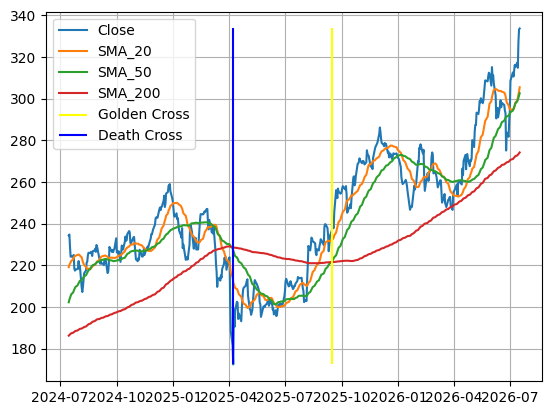

In [6]:
# TODO 1.2 — Plot close + SMA_20 + SMA_50 (last 2 years only)
# Mark Golden Cross (SMA_50 crosses above SMA_200) and Death Cross as vertical lines
# Hint: a cross occurs when the sign of (sma_50 - sma_200) changes

recent = df.tail(504)
#cross  = 
golden = (recent['sma_50'] > recent['sma_200']) & (recent['sma_50'].shift(1)<recent['sma_200'].shift(1))
death  = (recent['sma_50'] < recent['sma_200']) & (recent['sma_50'].shift(1)>recent['sma_200'].shift(1))

# Plot Graph
plt.plot(recent.index,recent['close'],label='Close')
plt.plot(recent.index,recent['sma_20'],label='SMA_20')
plt.plot(recent.index,recent['sma_50'],label='SMA_50')
plt.plot(recent.index,recent['sma_200'],label='SMA_200')
plt.vlines(recent.index[golden],recent['close'].min(),recent['close'].max(),colors='yellow',label='Golden Cross')
plt.vlines(recent.index[death],recent['close'].min(),recent['close'].max(),colors='blue',label='Death Cross')
plt.legend();plt.grid()
plt.show()


## 2. Exponential Moving Average (EMA)

Assigns exponentially decaying weights to past prices — more reactive to recent moves than SMA.

$$k = \frac{2}{n+1}, \qquad \text{EMA}(t) = C_t \cdot k + \text{EMA}(t-1)\cdot(1-k)$$

Also compute:
$$\text{ema\_ratio}_{20} = \frac{C_t}{\text{EMA}_{20}(t)} - 1$$

In [7]:
# TODO 2.1 — Compute EMA_12, EMA_20, EMA_26 and ema_ratio_20
df['ema_12']       = close.ewm(span=12 ,adjust=False).mean()
df['ema_20']       = close.ewm(span=20, adjust=False).mean()
df['ema_26']       = close.ewm(span=26 ,adjust=False).mean()
df['ema_ratio_20'] = close/df['ema_20'] -1

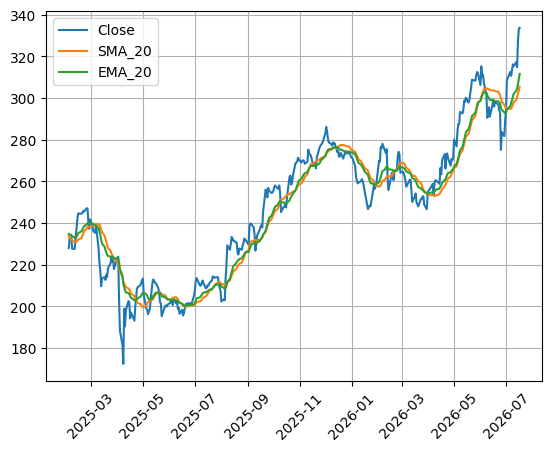

In [8]:
# TODO 2.2 — On a single chart, plot Close + SMA_20 + EMA_20 for the last 365 days
# Visually confirm: EMA reacts faster to price turns than SMA
recent =df.tail(365)
plt.plot(recent.index,recent['close'], label='Close')
plt.plot(recent.index,recent['sma_20'], label='SMA_20')
plt.plot(recent.index,recent['ema_20'],label='EMA_20')
plt.xticks(rotation= 45)
plt.legend();plt.grid();plt.show()

## 3. Relative Strength Index (RSI)

Momentum oscillator bounded in $[0, 100]$. Measures the ratio of average gains to average losses over $n$ days.

$$\Delta_t = C_t - C_{t-1}$$
$$G_t = \max(\Delta_t,\,0), \quad L_t = |\min(\Delta_t,\,0)|$$
$$\overline{G}_n = \text{EMA}_n(G), \quad \overline{L}_n = \text{EMA}_n(L)$$
$$RS = \frac{\overline{G}_n}{\overline{L}_n}, \quad \text{RSI} = 100 - \frac{100}{1 + RS}$$

Wilder's RSI uses $\alpha = 1/n$ (i.e. `com = n-1`) rather than the standard EMA span. RSI $> 70$: overbought. RSI $< 30$: oversold. Normalise to $[0, 1]$ before storing as a model feature.

In [9]:
# TODO 3.1 — Implement RSI with window=14; store normalised (÷100) as 'rsi_14'
# Use Wilder smoothing: ewm(com=n-1, adjust=False)

delta    = close.pct_change()
gain     = delta.where(delta>0,0)
loss     = (-delta).where(delta<0,0)
avg_gain = gain.ewm(com=13,adjust=False).mean()
avg_loss = loss.ewm(com=13, adjust=False).mean()
rs       = avg_gain/avg_loss
df['rsi_14'] = 1-1/(1+rs)


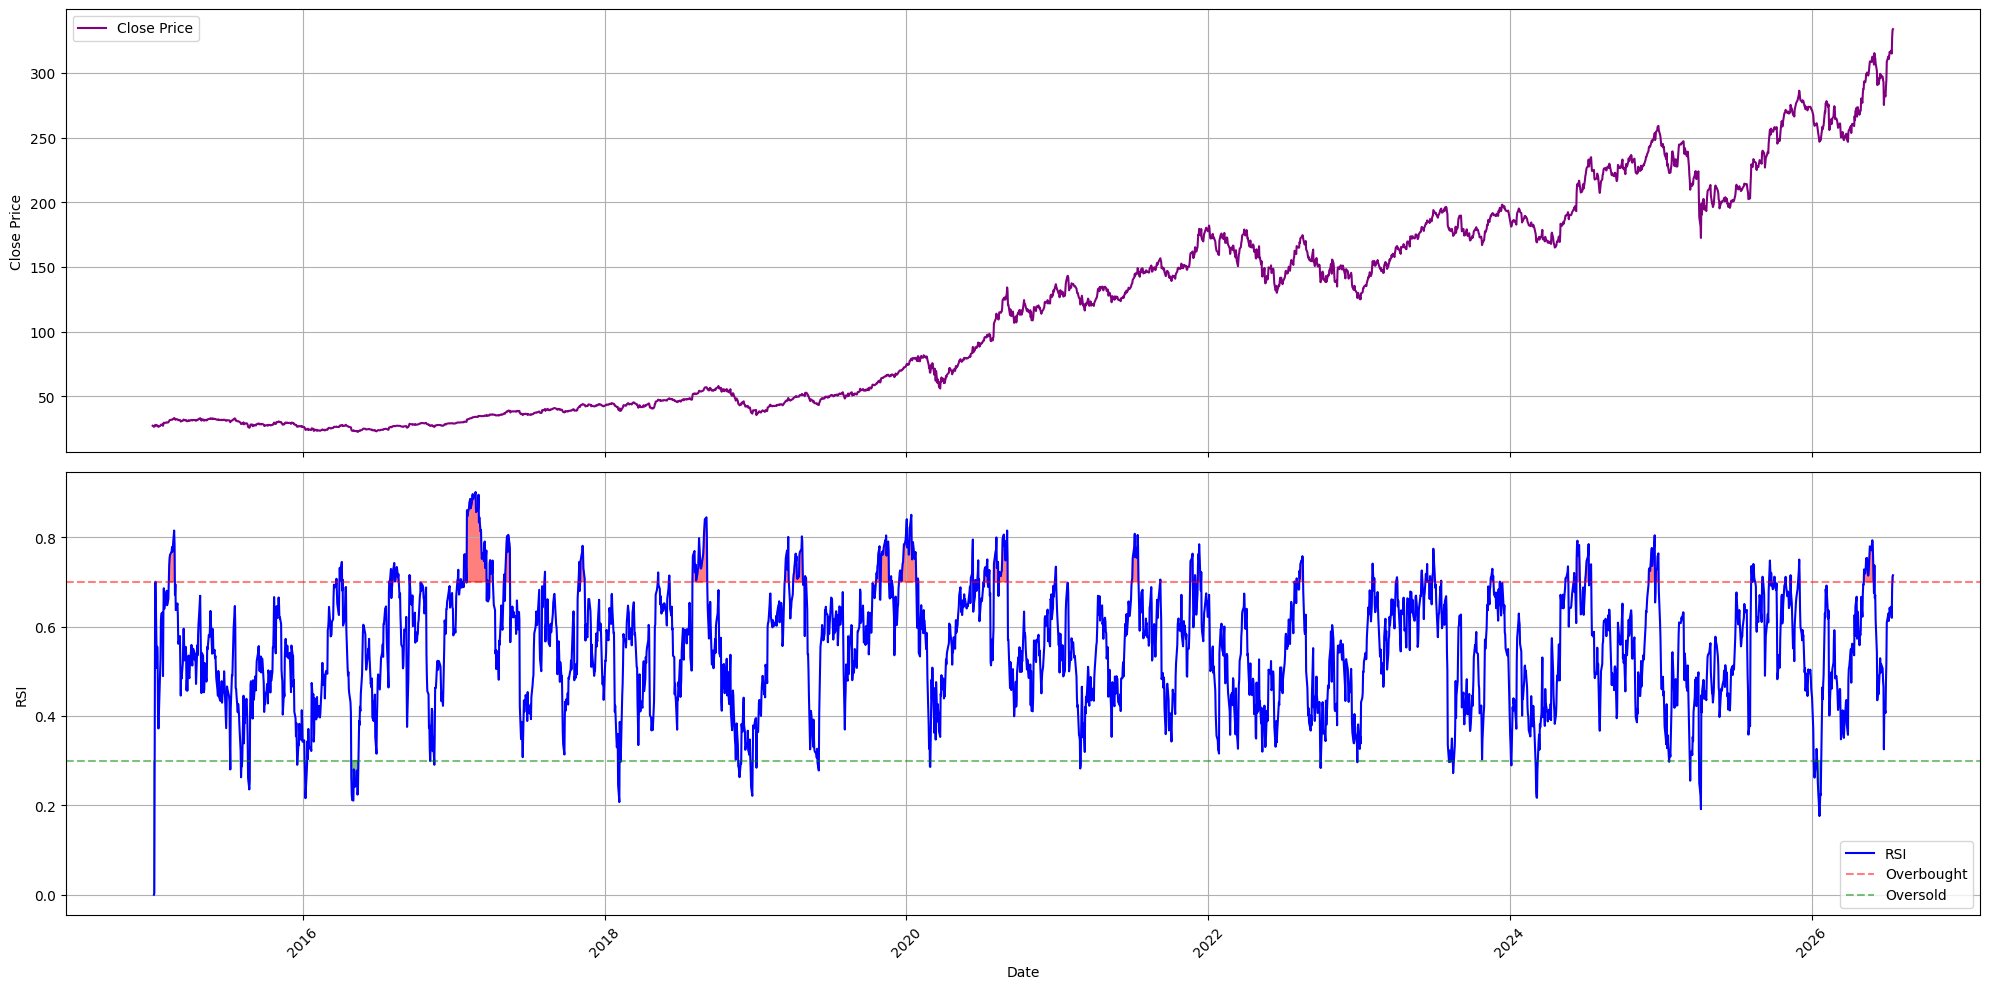

In [10]:
# TODO 3.2 — Two-panel chart: close (top) + RSI (bottom), sharex=True
# Dashed lines at 0.70 and 0.30; shade overbought in light red, oversold in light green

fig, (ax1,ax2) = plt.subplots(2,1,sharex=True,figsize=(20,10))
ax1.plot(df.index,close,color='purple',label='Close Price')
ax1.set_ylabel("Close Price")
ax1.grid()
ax1.legend()
ax2.plot(df.index,df['rsi_14'],color='blue',label="RSI")
ax2.axhline(0.7, color='red',label='Overbought',linestyle='--',alpha=0.5)
ax2.axhline(0.3, color='green',label='Oversold',linestyle='--',alpha=0.5)
ax2.fill_between(df.index,0.7,df['rsi_14'],where=(df['rsi_14'] >= 0.7),color='red',alpha=0.5)
ax2.fill_between(df.index,0.3,df['rsi_14'],where=(df['rsi_14'] <= 0.3),color='green', alpha=0.5)
ax2.legend()
ax2.set_xlabel("Date")
ax2.set_ylabel("RSI")
plt.xticks(rotation=45)
plt.grid()
plt.tight_layout()
plt.show()

## 4. MACD

Captures the convergence/divergence of two EMAs. Three outputs:

$$\text{MACD Line} = \text{EMA}_{12} - \text{EMA}_{26}$$
$$\text{Signal Line} = \text{EMA}_9(\text{MACD Line})$$
$$\text{Histogram} = \text{MACD Line} - \text{Signal Line}$$

Histogram sign-change → momentum shift. MACD crossing above Signal → bullish.

In [11]:
# TODO 4.1 — Compute macd, macd_signal, macd_hist using ema_12 and ema_26

df['macd']        = df['ema_12']-df['ema_26']
df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
df['macd_hist']   = df['macd']-df['macd_signal']

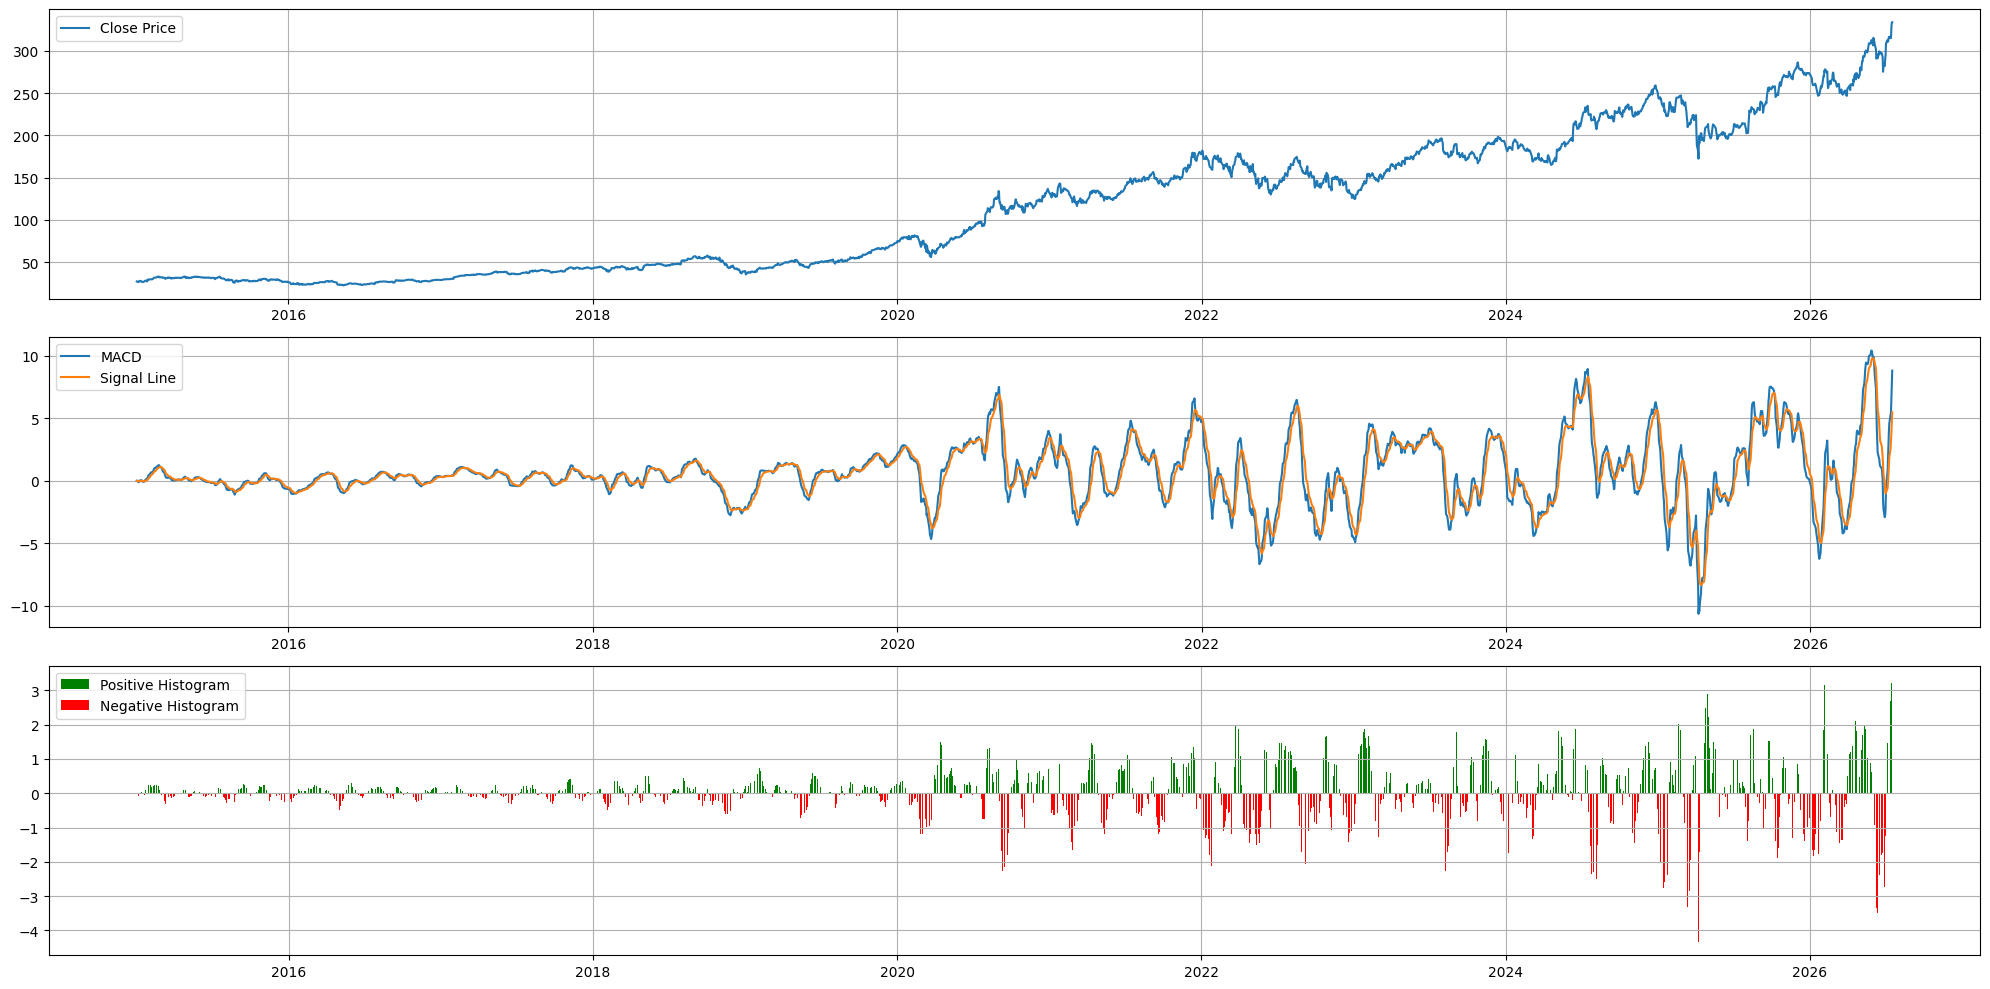

In [12]:
# TODO 4.2 — Three-panel chart: close | macd+signal | histogram coloured by sign
plt.figure(figsize=(20,10))
plt.subplot(3,1,1)
plt.plot(df.index,close,label='Close Price')
plt.grid()
plt.tight_layout()
plt.legend()
plt.subplot(3,1,2)
plt.plot(df.index,df['macd'],label='MACD')
plt.plot(df.index,df['macd_signal'],label='Signal Line')
plt.grid()
plt.tight_layout()
plt.legend()
plt.subplot(3,1,3)
pos=df['macd_hist'][df['macd_hist']>=0]
neg=df['macd_hist'][df['macd_hist']<0]
plt.bar(pos.index,pos, color='green',label='Positive Histogram')
plt.bar(neg.index,neg, color='red' , label='Negative Histogram')
plt.legend()
plt.grid()
plt.tight_layout()

## 5. Bollinger Bands

Places volatility-scaled envelopes around the 20-day SMA.

$$\text{Upper} = \text{SMA}_{20} + k\cdot\sigma_{20}, \quad \text{Lower} = \text{SMA}_{20} - k\cdot\sigma_{20}, \quad k=2$$

Two derived features used as model inputs:

| Feature | Formula |
|---|---|
| **BB Width** | $\frac{\text{Upper} - \text{Lower}}{C_t}$ — proxy for volatility |
| **%B** | $\frac{C_t - \text{Lower}}{\text{Upper} - \text{Lower}}$ — position within bands |

In [13]:
# TODO 5 — Compute bb_upper, bb_lower, bb_width, bb_pct_b

rolling_std    = close.rolling(window=20).std()
df['bb_upper'] = df['sma_20']+2*rolling_std
df['bb_lower'] = df['sma_20']-2*rolling_std
df['bb_width'] = (df['bb_upper']-df['bb_lower'])/close
df['bb_pct_b'] = (close - df['bb_lower'])/(df['bb_upper']-df['bb_lower'])


## 6. Rate of Change (ROC)

Measures momentum as the percentage change over $n$ periods.

$$\text{ROC}_n(t) = \frac{C_t - C_{t-n}}{C_{t-n}} \times 100$$

Compute for $n = 5$ and $n = 10$.

In [14]:
# TODO 6 — Compute roc_5 and roc_10

df['roc_5']  = (close-close.shift(5))*100/close.shift(5)
df['roc_10'] = (close-close.shift(10))*100/close.shift(10)

## 7. Average True Range (ATR)

Measures volatility using all three price extremes. Unlike rolling return std, ATR accounts for overnight gaps.

$$TR_t = \max\bigl(H_t - L_t,\;|H_t - C_{t-1}|,\;|L_t - C_{t-1}|\bigr)$$

$$\text{ATR}_{14}(t) = \text{EMA}_{14}(TR) \quad\text{(Wilder smoothing: }\alpha = 1/n\text{)}$$

Normalise by close to make it comparable across symbols:
$$\text{atr\_ratio} = \frac{\text{ATR}_{14}}{C_t}$$

In [15]:
# TODO 7 — Compute true_range, atr_14, atr_ratio
# Use Wilder smoothing (ewm with com=13, adjust=False)

prev_close = close.shift(1)
true_range = pd.Series(np.maximum.reduce([(high-low),np.abs(high-prev_close),np.abs(low-prev_close)]), index=df.index)
df['atr_14']    = true_range.ewm(com=13,adjust=False).mean()
df['atr_ratio'] = df['atr_14']/close

## 8. Stochastic Oscillator (%K and %D)

Compares the closing price to the price range over a lookback window.

$$\%K_n(t) = \frac{C_t - \min_n(L)}{\max_n(H) - \min_n(L)} \times 100$$

$$\%D = \text{SMA}_3(\%K) \quad \text{(signal smoothing)}$$

Use $n = 14$. Normalise both to $[0, 1]$. Store as `stoch_k` and `stoch_d`.

In [16]:
# TODO 8.1 — Compute stoch_k and stoch_d

lowest_low   = low.rolling(window=14).min()
highest_high = high.rolling(window=14).max()
df['stoch_k'] = (close-lowest_low)/(highest_high-lowest_low)
df['stoch_d'] = df['stoch_k'].rolling(window=3).mean()

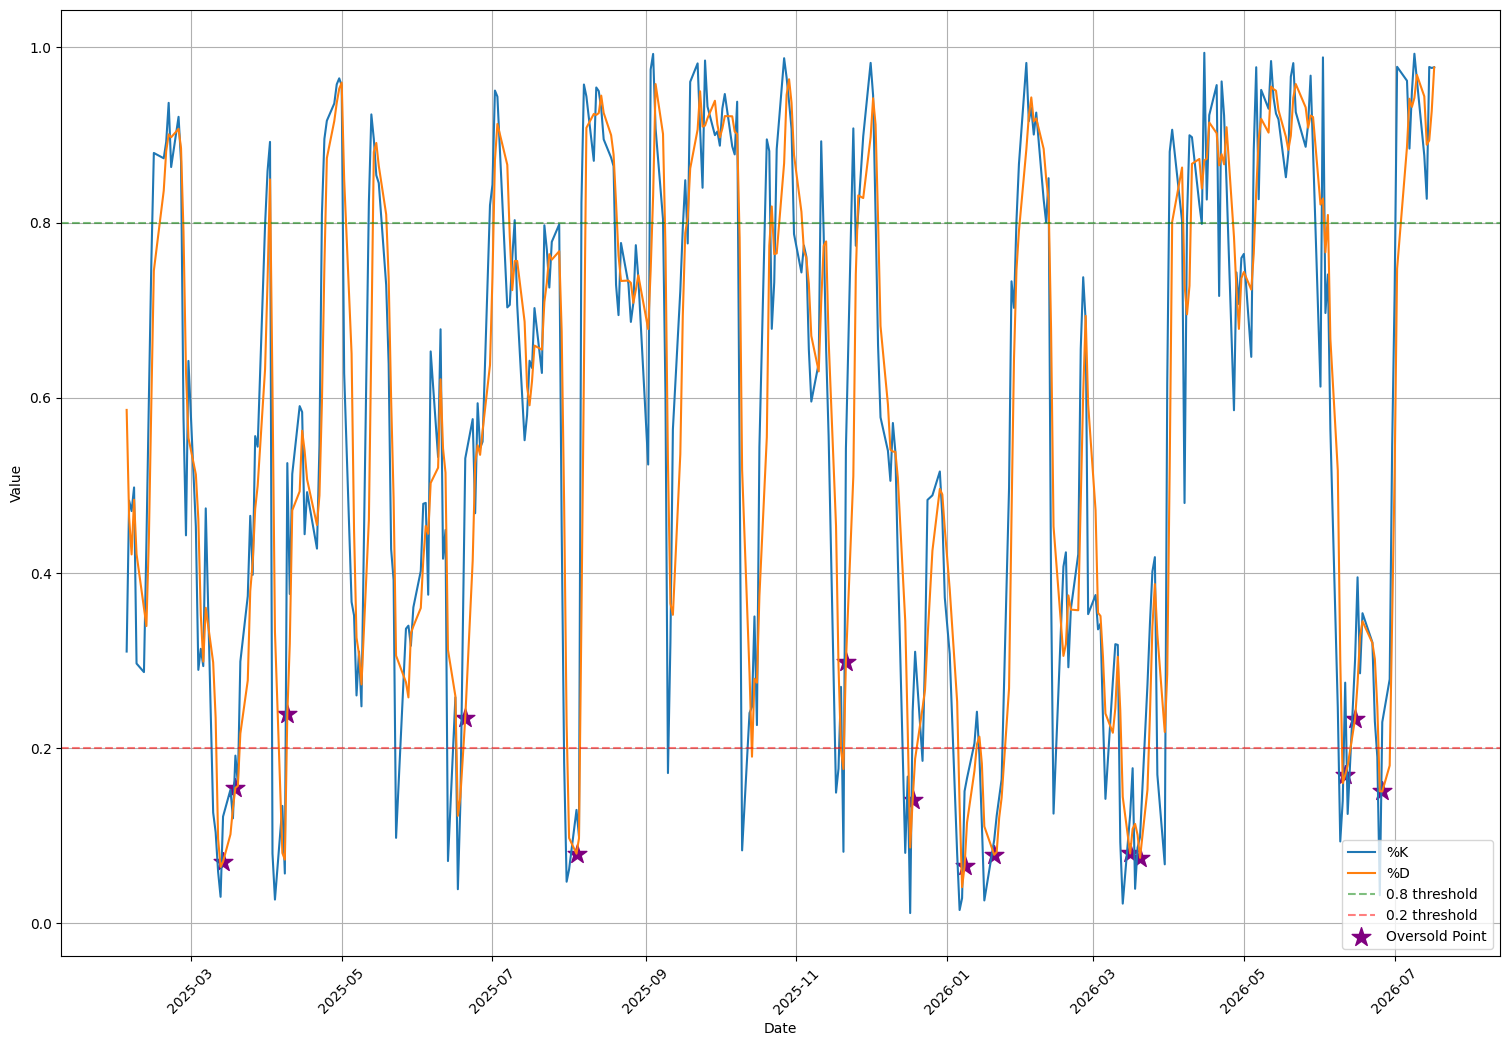

In [17]:
# TODO 8.2 — Plot stoch_k and stoch_d, last 365 days
# Mark 0.80 and 0.20 thresholds
# When %K crosses above %D from below the oversold zone → classic buy signal
recent=df.tail(365)
plt.figure(figsize=(15,10))
plt.plot(recent.index,recent['stoch_k'],label='%K')
plt.plot(recent.index,recent['stoch_d'],label='%D')
plt.axhline(0.8,color='green',label='0.8 threshold',linestyle='--',alpha=0.5)
plt.axhline(0.2,color='red',label='0.2 threshold',linestyle='--',alpha=0.5)
oversold=recent['stoch_d'][((recent['stoch_k']>=recent['stoch_d']) & (recent['stoch_k'].shift(1)<recent['stoch_d'].shift(1)) &(recent['stoch_d'].shift(1)<0.2)&(recent['stoch_k'].shift(1)<0.2))]
plt.scatter(oversold.index,oversold.values,marker='*',color='purple',label='Oversold Point',s=200)
plt.grid()
plt.legend()
plt.tight_layout()
plt.xlabel('Date')
plt.ylabel('Value')
plt.xticks(rotation=45)
plt.show()



## 9. On-Balance Volume (OBV)

Cumulative volume indicator — adds volume on up-days, subtracts it on down-days. Used to detect whether volume confirms or diverges from a price trend.

$$\text{OBV}(t) = \text{OBV}(t-1) + \begin{cases} +V_t & C_t > C_{t-1} \\ -V_t & C_t < C_{t-1} \\ 0 & C_t = C_{t-1} \end{cases}$$

Store the **percentage change** of OBV as the model feature: $\text{obv\_change} = \frac{\text{OBV}(t) - \text{OBV}(t-1)}{|\text{OBV}(t-1)|}$

In [18]:
# TODO 9 — Compute obv and obv_change
# np.sign(close.diff()) gives +1 / 0 / -1 for each day's direction

direction       = np.sign(close.diff())
df['obv']       = (direction*volume).cumsum()
df['obv_change']= (df['obv']-df['obv'].shift(1))/np.abs(df['obv'].shift(1))

## 10. Volume-Weighted Average Price (VWAP)

The price level weighted by volume — a fair-value benchmark widely used by institutional traders.

We compute a **rolling 20-day VWAP** using the typical price:

$$P_{\text{typ}}(t) = \frac{H_t + L_t + C_t}{3}$$

$$\text{VWAP}_{20}(t) = \frac{\sum_{i=0}^{19} P_{\text{typ}}(t{-}i)\cdot V_{t{-}i}}{\sum_{i=0}^{19} V_{t{-}i}}$$

Normalise: $\text{vwap\_ratio} = C_t / \text{VWAP} - 1$

In [19]:
# TODO 10 — Compute rolling VWAP (20-day) and vwap_ratio

typical_price   = (high+low+close)/3
tp_vol          = typical_price*volume
df['vwap']       = tp_vol.rolling(window=20).sum()/volume.rolling(window=20).sum()
df['vwap_ratio'] = close/df['vwap'] -1


## 11. Build & Save the Feature Dataset

Combine all indicators into a clean DataFrame and save to `data/processed/`.
This CSV will be loaded directly by the model notebooks in later weeks.

In [20]:
FEATURE_COLUMNS = [
    'return_1', 'return_5', 'log_return_1',
    'sma_ratio_20', 'sma_ratio_50',
    'ema_ratio_20',
    'rsi_14',
    'macd', 'macd_signal',
    'roc_5', 'roc_10',
    'bb_width', 'bb_pct_b',
    'atr_ratio',
    'stoch_k', 'stoch_d',
    'obv_change',
    'vwap_ratio',
]

In [21]:
# TODO 11.1 — Add target columns, clean, and save
# 'future_return'    = next-day return  (close shifted -1 divided by close, minus 1)
# 'target_direction' = 1 if future_return > 0, else 0
#
# Then:
#   1. Replace inf / -inf with NaN
#   2. Drop rows where ANY required column is NaN
#   3. Reset index so 'date' becomes a regular column again
#   4. Save to  PROCESSED_DIR / f'{safe_symbol(SYMBOL)}_features.csv'
#   5. Print the output path and shape; show .describe() of required columns

df['future_return']    = close.shift(-1)/close -1
df['target_direction'] = [1 if v>0 else 0 for v in df['future_return']]

required = FEATURE_COLUMNS + ['future_return','target_direction']
df       = df[required]
df       = df.replace([float('inf'),float('-inf')],float('NaN'))

df_clean = df[required].dropna()
df_clean = df_clean.reset_index()


out_path = PROCESSED_DIR/"AAPL_features.csv"
df_clean.to_csv(out_path)
print(out_path,df_clean.shape)
df_clean[required].describe().round(4)

data\processed\AAPL_features.csv (2851, 21)


,return_1,return_5,log_return_1,sma_ratio_20,sma_ratio_50,ema_ratio_20,rsi_14,macd,macd_signal,roc_5,roc_10,bb_width,bb_pct_b,atr_ratio,stoch_k,stoch_d,obv_change,vwap_ratio,future_return,target_direction
count,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000,2851.0000
mean,0.0010,0.0048,0.0008,0.0080,0.0209,0.0076,0.5531,0.6619,0.6562,0.4845,0.9567,0.1156,0.5806,0.0224,0.5904,0.5901,0.0272,0.0095,0.0010,0.5286
std,0.0181,0.0384,0.0181,0.0422,0.0692,0.0363,0.1284,2.5182,2.3499,3.8417,5.3637,0.0565,0.3280,0.0082,0.3093,0.2898,1.5559,0.0410,0.0181,0.4993
min,-0.1286,-0.2275,-0.1377,-0.1861,-0.2482,-0.1813,0.1761,-10.6409,-8.3474,-22.7474,-22.9408,0.0306,-0.2992,0.0091,0.0000,0.0059,-30.3715,-0.1633,-0.1286,0.0000
25%,-0.0074,-0.0173,-0.0074,-0.0179,-0.0219,-0.0140,0.4587,-0.5198,-0.4424,-1.7332,-2.3349,0.0736,0.3087,0.0168,0.3077,0.3198,-0.0295,-0.0167,-0.0074,0.0000
50%,0.0009,0.0063,0.0009,0.0118,0.0248,0.0114,0.5599,0.4208,0.3850,0.6289,1.2435,0.1055,0.6446,0.0205,0.6607,0.6581,0.0068,0.0125,0.0009,1.0000
75%,0.0099,0.0272,0.0098,0.0367,0.0679,0.0314,0.6478,1.8285,1.7706,2.7161,4.4273,0.1437,0.8471,0.0256,0.8763,0.8558,0.0371,0.0384,0.0099,1.0000
max,0.1533,0.1841,0.1426,0.1475,0.2796,0.1337,0.9010,10.4244,9.8065,18.4141,22.6803,0.4257,1.3701,0.0776,1.0000,0.9977,60.7091,0.1494,0.1533,1.0000


In [22]:
# TODO 11.2 (Challenge) — Run the full pipeline for atleast one downloaded symbols
# To process for all symbol change the symbol above rerun all cells to get features of that symbol.
# Loop over every CSV in RAW_DIR, compute all indicators, save to PROCESSED_DIR.
# Wrap each symbol in try/except so one failure does not stop the loop.
# Print a summary table at the end with columns:
#   symbol | rows_raw | rows_processed | drop_pct

summary = []
for csv_path in RAW_DIR.glob('*.csv'):
    sym = csv_path.stem
    try:
        raw       = csv_path
        df=pd.read_csv(raw) 
        df['date']=pd.to_datetime(df['date'])
        df.set_index('date',inplace=True)
        df.sort_values('date',inplace=True)
        df.columns=df.columns.str.lower()
        df['volume']=df['volume'].replace(0,float('NaN'))


        
        close  = df['close']
        high   = df['high']
        low    = df['low']
        volume = df['volume']


        return_1     = close.pct_change()
        return_5     = close.pct_change(periods=5)
        log_return_1 = np.log(close/close.shift(1))

        df['return_1']     = return_1
        df['return_5']     = return_5
        df['log_return_1'] = log_return_1


        df['sma_20']      = close.rolling(window=20).mean()
        df['sma_50']      = close.rolling(window=50).mean()
        df['sma_200']     = close.rolling(window=200).mean()
        df['sma_ratio_20'] = close/df['sma_20'] - 1
        df['sma_ratio_50'] = close/df['sma_50'] - 1


        df['ema_12']       = close.ewm(span=12 ,adjust=False).mean()
        df['ema_20']       = close.ewm(span=20, adjust=False).mean()
        df['ema_26']       = close.ewm(span=26 ,adjust=False).mean()
        df['ema_ratio_20'] = close/df['ema_20'] -1


        delta    = close.pct_change()
        gain     = delta.where(delta>0,0)
        loss     = (-delta).where(delta<0,0)
        avg_gain = gain.ewm(com=13,adjust=False).mean()
        avg_loss = loss.ewm(com=13, adjust=False).mean()
        rs       = avg_gain/avg_loss
        df['rsi_14'] = 1-1/(1+rs)


        df['macd']        = df['ema_12']-df['ema_26']
        df['macd_signal'] = df['macd'].ewm(span=9, adjust=False).mean()
        df['macd_hist']   = df['macd']-df['macd_signal']


        rolling_std    = close.rolling(window=20).std()
        df['bb_upper'] = df['sma_20']+2*rolling_std
        df['bb_lower'] = df['sma_20']-2*rolling_std
        df['bb_width'] = (df['bb_upper']-df['bb_lower'])/close
        df['bb_pct_b'] = (close - df['bb_lower'])/(df['bb_upper']-df['bb_lower'])


        df['roc_5']  = (close-close.shift(5))*100/close.shift(5)
        df['roc_10'] = (close-close.shift(10))*100/close.shift(10)


        prev_close = close.shift(1)
        true_range = pd.Series(np.maximum.reduce([(high-low),np.abs(high-prev_close),np.abs(low-prev_close)]), index=df.index)
        df['atr_14']    = true_range.ewm(com=13,adjust=False).mean()
        df['atr_ratio'] = df['atr_14']/close


        lowest_low   = low.rolling(window=14).min()
        highest_high = high.rolling(window=14).max()
        df['stoch_k'] = (close-lowest_low)/(highest_high-lowest_low)
        df['stoch_d'] = df['stoch_k'].rolling(window=3).mean()


        direction       = np.sign(close.diff())
        df['obv']       = (direction*volume).cumsum()
        df['obv_change']= (df['obv']-df['obv'].shift(1))/np.abs(df['obv'].shift(1))


        typical_price   = (high+low+close)/3
        tp_vol          = typical_price*volume
        df['vwap']       = tp_vol.rolling(window=20).sum()/volume.rolling(window=20).sum()
        df['vwap_ratio'] = close/df['vwap'] -1
        df['z_score_20'] = (close-close.rolling(window=20).mean())/close.rolling(window=20).std()

#         # ... compute all indicators on raw ...
        
        processed = PROCESSED_DIR / f"{sym}_features.csv"

        FEATURE_COLUMNS = [ "open", "high", "low", "close", "volume",
           'return_1', 'return_5', 'log_return_1','sma_20','sma_50','sma_200',
           'sma_ratio_20', 'sma_ratio_50','ema_12','ema_20','ema_26',
            'ema_ratio_20',
            'rsi_14',
            'macd', 'macd_signal','macd_hist',
            'roc_5', 'roc_10','bb_upper','bb_lower',
            'bb_width', 'bb_pct_b','atr_14',
            'atr_ratio',
            'stoch_k', 'stoch_d','obv',
            'obv_change','vwap',
            'vwap_ratio',
            'z_score_20'
        ]


        df['future_return']    = close.shift(-1)/close -1
        df['target_direction'] = [1 if v>0 else 0 for v in df['future_return']]
        rows_raw=df.shape[0]
        required = FEATURE_COLUMNS + ['future_return','target_direction']
        df       = df[required]
        df       = df.replace([float('inf'),float('-inf')],float('NaN'))
        
        df_clean = df[required].dropna()
        df_clean = df_clean.reset_index()
        rows_processed = df_clean.shape[0]
        df_clean.to_csv(processed)
#         # ... save to PROCESSED_DIR ...
        summary.append({'symbol' :sym,'rows_raw' :rows_raw,'rows_processed' :rows_processed ,'drop_pct' :round((rows_raw-rows_processed)*100/rows_raw,2)})

    except Exception as e:
        summary.append({'symbol': sym, 'error': str(e)})

pd.DataFrame(summary)

,symbol,rows_raw,rows_processed,drop_pct
0,AAPL,2901,2701,6.89
1,BSESN,2839,2517,11.34
2,BTC_USD,4218,4018,4.74
3,ETH_USD,3175,2975,6.30
4,EURUSD_X,3004,0,100.00
5,GSPC,2901,2681,7.58
6,INFY_NS,2852,2558,10.31
7,IXIC,2901,2701,6.89
8,JPY_X,3004,0,100.00
9,MSFT,2901,2701,6.89


---
